In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

BASE_DIR = ".."

TASK_B_DIR = os.path.join(BASE_DIR, "results", "task_b")
TASK_C_DIR = os.path.join(BASE_DIR, "results", "task_c")
FINAL_DIR = os.path.join(BASE_DIR, "results", "final")

os.makedirs(FINAL_DIR, exist_ok=True)

TASK_B_SUMMARY = os.path.join(TASK_B_DIR, "final_summary.csv")
TASK_C_METRICS = os.path.join(TASK_C_DIR, "dl_metrics.csv")
TASK_C_PREDICTIONS = os.path.join(TASK_C_DIR, "dl_predictions.pkl")

print("Task B summary:", TASK_B_SUMMARY)
print("Task C metrics:", TASK_C_METRICS)
print("Task C predictions:", TASK_C_PREDICTIONS)

Task B summary: ..\results\task_b\final_summary.csv
Task C metrics: ..\results\task_c\dl_metrics.csv
Task C predictions: ..\results\task_c\dl_predictions.pkl


In [2]:
task_b = pd.read_csv(TASK_B_SUMMARY)

print("Task B result:")
display(task_b)

Task B result:


,Model,DS1 Baseline,DS1 Tuned Val,DS1 Test,DS2 Baseline,DS2 Tuned Val,DS2 Test
0,KNN,0.6467,0.6567,0.6509,0.6387,0.6387,0.6502
1,Random Forest,0.7367,0.7393,0.7076,0.6627,0.6540,0.7043
2,SVM,0.7487,0.7447,0.6963,0.7240,0.7240,0.7076
3,XGBoost,0.7727,0.7733,0.7316,0.7100,0.7293,0.7310


In [3]:
task_c_metrics = pd.read_csv(TASK_C_METRICS)

print("Task C metrics:")
display(task_c_metrics)

Task C metrics:


,model,accuracy,f1_macro,f1_weighted,notes
0,CNN2D_BiLSTM,0.8011,0.7925,0.7955,"CNN2D+BiLSTM on Mel Spectrogram, GroupShuffleS..."


In [4]:
with open(TASK_C_PREDICTIONS, "rb") as f:
    dl_pred = pickle.load(f)

print("Prediction file type:", type(dl_pred))
print("Main keys:", dl_pred.keys())

cnn_lstm = dl_pred["CNN_LSTM"]
genres = dl_pred["genres"]

print("CNN_LSTM keys:", cnn_lstm.keys())
print("Genres:", genres)

y_test = cnn_lstm["y_test"]
y_pred = cnn_lstm["y_pred"]

print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)

Prediction file type: <class 'dict'>
Main keys: dict_keys(['CNN_LSTM', 'genres'])
CNN_LSTM keys: dict_keys(['accuracy', 'y_pred', 'y_test'])
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
y_test shape: (1498,)
y_pred shape: (1498,)


In [5]:
cnn_metrics = {
    "Model": "CNN2D_BiLSTM",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "Recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "F1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "F1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0)
}

cnn_metrics_df = pd.DataFrame([cnn_metrics])

print("CNN2D_BiLSTM evaluation:")
display(cnn_metrics_df)

cnn_metrics_df.to_csv(
    os.path.join(FINAL_DIR, "cnn_lstm_metrics.csv"),
    index=False
)

CNN2D_BiLSTM evaluation:


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted
0,CNN2D_BiLSTM,0.801068,0.794246,0.801731,0.792506,0.795523


In [6]:
report = classification_report(
    y_test,
    y_pred,
    target_names=genres,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

print("Classification report:")
display(report_df)

report_df.to_csv(
    os.path.join(FINAL_DIR, "cnn_lstm_classification_report.csv")
)

Classification report:


,precision,recall,f1-score,support
blues,0.941606,0.716667,0.813880,180.000000
classical,0.787402,1.000000,0.881057,100.000000
country,0.817647,0.926667,0.868750,150.000000
disco,0.789809,0.826667,0.807818,150.000000
hiphop,0.800000,0.727273,0.761905,99.000000
jazz,0.843220,0.904545,0.872807,220.000000
metal,0.873418,0.985714,0.926174,140.000000
pop,0.709677,0.785714,0.745763,140.000000
reggae,0.741379,0.678947,0.708791,190.000000
rock,0.638298,0.465116,0.538117,129.000000


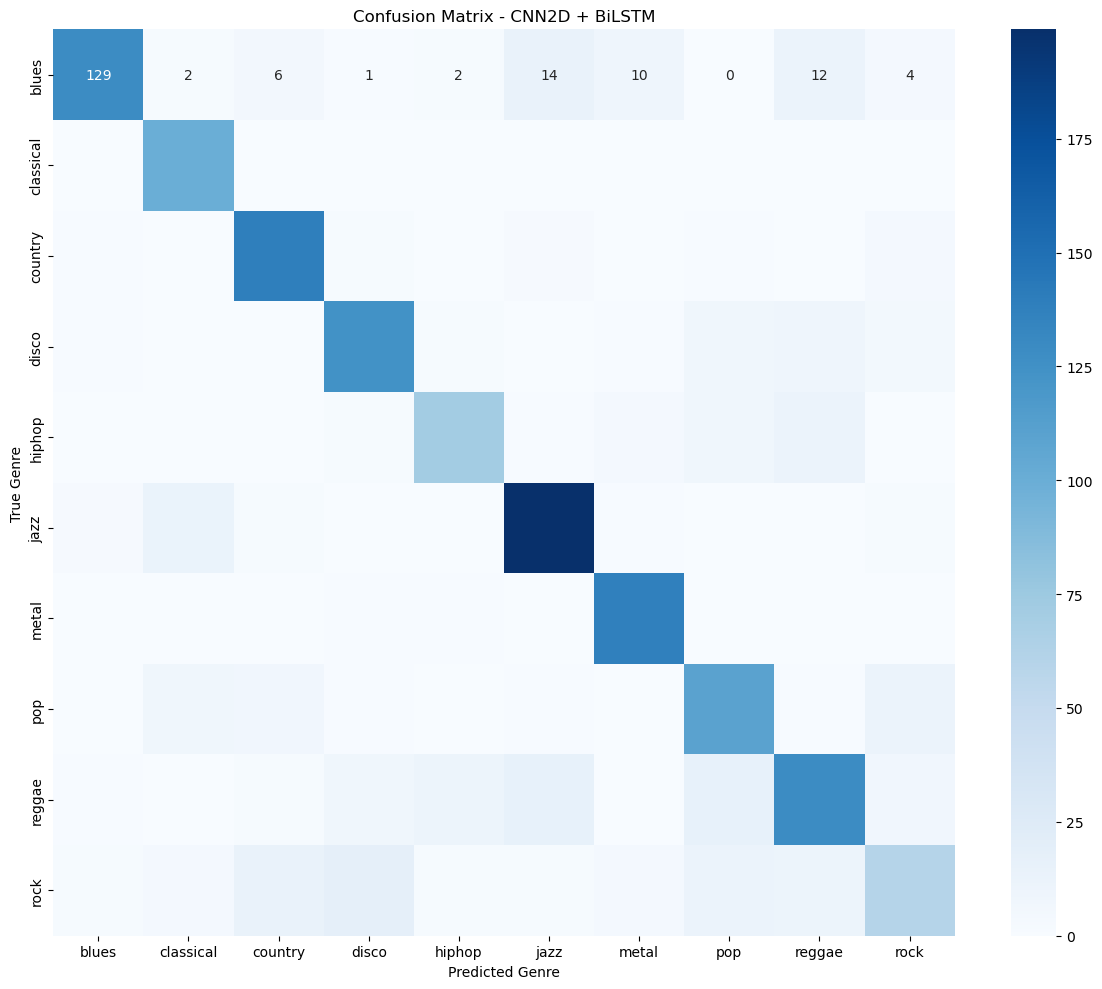

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=genres,
    yticklabels=genres
)

plt.title("Confusion Matrix - CNN2D + BiLSTM")
plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")

plt.tight_layout()

plt.savefig(
    os.path.join(FINAL_DIR, "cnn_lstm_confusion_matrix.png"),
    dpi=300
)

plt.show()

In [8]:
cm = confusion_matrix(y_test, y_pred)

error_rows = []

for i, genre in enumerate(genres):
    total = cm[i].sum()
    correct = cm[i, i]

    if total == 0:
        acc = 0
    else:
        acc = correct / total

    confused = []

    for j in range(len(genres)):
        if i != j and cm[i, j] > 0:
            confused.append((genres[j], cm[i, j]))

    confused = sorted(confused, key=lambda x: x[1], reverse=True)

    if len(confused) > 0:
        most_confused_with = confused[0][0]
        confused_count = confused[0][1]
    else:
        most_confused_with = "None"
        confused_count = 0

    error_rows.append({
        "Genre": genre,
        "Class Accuracy": round(acc, 4),
        "Correct": int(correct),
        "Total": int(total),
        "Most Confused With": most_confused_with,
        "Confused Count": int(confused_count)
    })

error_df = pd.DataFrame(error_rows).sort_values("Class Accuracy")

display(error_df)

error_df.to_csv(
    os.path.join(FINAL_DIR, "genre_error_analysis.csv"),
    index=False
)

,Genre,Class Accuracy,Correct,Total,Most Confused With,Confused Count
9,rock,0.4651,60,129,disco,18
8,reggae,0.6789,129,190,jazz,16
0,blues,0.7167,129,180,jazz,14
4,hiphop,0.7273,72,99,reggae,12
7,pop,0.7857,110,140,rock,12
3,disco,0.8267,124,150,reggae,9
5,jazz,0.9045,199,220,classical,13
2,country,0.9267,139,150,rock,4
6,metal,0.9857,138,140,disco,1
1,classical,1.0000,100,100,None,0


In [9]:
task_b_compare = task_b.copy()

print("Task B columns:")
print(task_b_compare.columns.tolist())

# Ưu tiên lấy cột DS1 Test nếu có
if "DS1 Test" in task_b_compare.columns:
    task_b_acc_col = "DS1 Test"
elif "DS2 Test" in task_b_compare.columns:
    task_b_acc_col = "DS2 Test"
else:
    raise ValueError("Không tìm thấy cột test accuracy trong Task B.")

compare_df = pd.DataFrame({
    "Model": task_b_compare["Model"],
    "Accuracy": task_b_compare[task_b_acc_col],
    "Source": "Task B"
})

display(compare_df)

Task B columns:
['Model', 'DS1 Baseline', 'DS1 Tuned Val', 'DS1 Test', 'DS2 Baseline', 'DS2 Tuned Val', 'DS2 Test']


,Model,Accuracy,Source
0,KNN,0.6509,Task B
1,Random Forest,0.7076,Task B
2,SVM,0.6963,Task B
3,XGBoost,0.7316,Task B


In [10]:
compare_df = pd.concat([
    compare_df,
    pd.DataFrame([{
        "Model": "CNN2D_BiLSTM",
        "Accuracy": cnn_metrics["Accuracy"],
        "Source": "Task C"
    }])
], ignore_index=True)

compare_df = compare_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)

print("Final model comparison:")
display(compare_df)

compare_df.to_csv(
    os.path.join(FINAL_DIR, "model_comparison.csv"),
    index=False
)

Final model comparison:


,Model,Accuracy,Source
0,CNN2D_BiLSTM,0.801068,Task C
1,XGBoost,0.731600,Task B
2,Random Forest,0.707600,Task B
3,SVM,0.696300,Task B
4,KNN,0.650900,Task B


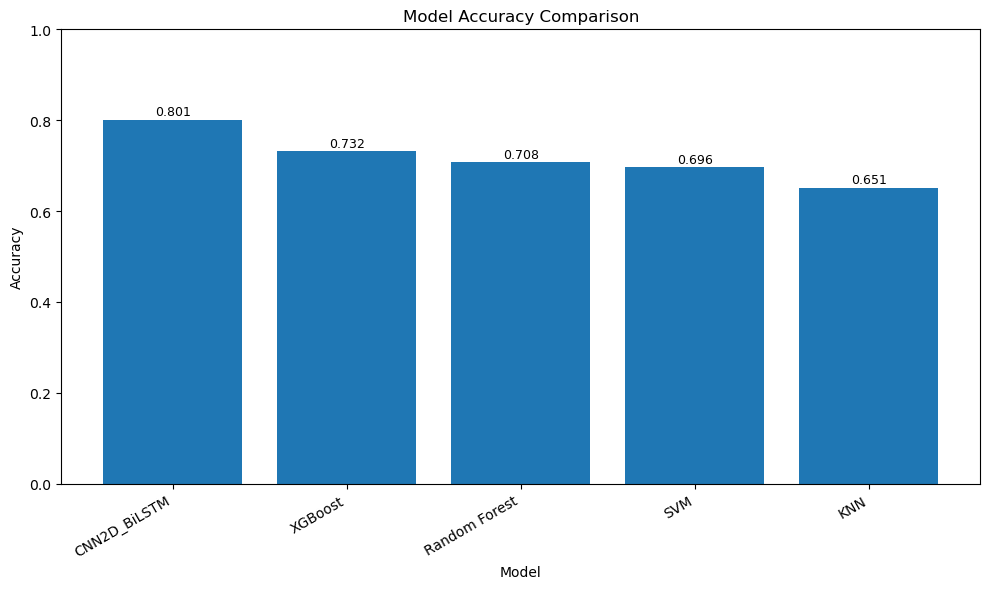

In [11]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    compare_df["Model"],
    compare_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    os.path.join(FINAL_DIR, "model_accuracy_comparison.png"),
    dpi=300
)

plt.show()

In [12]:
f1_compare = pd.DataFrame([{
    "Model": "CNN2D_BiLSTM",
    "F1_macro": cnn_metrics["F1_macro"],
    "F1_weighted": cnn_metrics["F1_weighted"],
    "Source": "Task C"
}])

display(f1_compare)

f1_compare.to_csv(
    os.path.join(FINAL_DIR, "f1_comparison.csv"),
    index=False
)

,Model,F1_macro,F1_weighted,Source
0,CNN2D_BiLSTM,0.792506,0.795523,Task C


In [13]:
best_model = compare_df.iloc[0]

summary_text = f"""
FINAL EVALUATION SUMMARY

Best model: {best_model['Model']}
Best accuracy: {best_model['Accuracy']:.4f}

CNN2D_BiLSTM metrics:
- Accuracy: {cnn_metrics['Accuracy']:.4f}
- Precision macro: {cnn_metrics['Precision_macro']:.4f}
- Recall macro: {cnn_metrics['Recall_macro']:.4f}
- F1 macro: {cnn_metrics['F1_macro']:.4f}
- F1 weighted: {cnn_metrics['F1_weighted']:.4f}

Comments:
- Traditional machine learning models from Task B achieve strong performance on extracted audio features.
- The CNN2D_BiLSTM model from Task C uses Mel Spectrogram input and captures temporal-spatial patterns in audio.
- The confusion matrix helps identify which music genres are frequently misclassified.
- The final comparison table provides a basis for selecting the best model for deployment or demo.
"""

print(summary_text)

with open(os.path.join(FINAL_DIR, "evaluation_summary.txt"), "w", encoding="utf-8") as f:
    f.write(summary_text)


FINAL EVALUATION SUMMARY

Best model: CNN2D_BiLSTM
Best accuracy: 0.8011

CNN2D_BiLSTM metrics:
- Accuracy: 0.8011
- Precision macro: 0.7942
- Recall macro: 0.8017
- F1 macro: 0.7925
- F1 weighted: 0.7955

Comments:
- Traditional machine learning models from Task B achieve strong performance on extracted audio features.
- The CNN2D_BiLSTM model from Task C uses Mel Spectrogram input and captures temporal-spatial patterns in audio.
- The confusion matrix helps identify which music genres are frequently misclassified.
- The final comparison table provides a basis for selecting the best model for deployment or demo.

